# 음성정보처리 Chapter 3 전처리(Pre-processing) — librosa 실습

- 대상: 파이썬 초급 / 음성신호처리 입문
- 구성: 이론 강의 한 단위 종료 후 해당 실습 셀 순차 실행
- 실행 원칙: 위에서 아래로 순서대로 실행 (앞 셀의 변수를 뒤 셀에서 사용)
- 학습 목표: 코드 암기가 아닌 파라미터 변경에 따른 결과 변화 관찰

| 실습 | 주제 | 교재 |
|---|---|---|
| 0 | 실습 환경 준비 / 음성 불러오기 | — |
| 1 | 프리엠퍼시스 | 3.1 |
| 2 | 노이즈 게이트 | 3.2 |
| 3 | 동적 범위 압축 | 3.3 |
| 4 | 음성 활동 검출(VAD) | 3.4 |
| 5 | 성도 길이 정규화(VTLN) | 3.5 |
| 6 | 음성 향상 | 3.6 |
| 7 | 전처리 파이프라인 종합 | — |

## 실습 0. 실습 환경 준비

- 설치 명령(최초 1회): `pip install librosa soundfile matplotlib scipy`
- 선택 설치(음성 향상 평가 지표): `pip install pystoi pesq`
- 공통 분석 조건: 16 kHz 샘플링 / 프레임 25 ms / 이동 10 ms / FFT 512점

In [2]:
import logging, warnings
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sps
import scipy.ndimage as ndi
from scipy.interpolate import interp1d
import librosa, librosa.display
from IPython.display import Audio, display

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic",
                               "Noto Sans CJK KR", "Noto Sans CJK JP", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

SR    = 16000   # 샘플링 레이트 (Hz)
FRAME = 400     # 프레임 길이 25 ms
HOP   = 160     # 프레임 이동 10 ms
N_FFT = 512     # FFT 길이 32 ms
print("librosa", librosa.__version__)

librosa 1.0.0


In [3]:
import os, urllib.request

URL = "https://raw.githubusercontent.com/librosa/data/main/audio/5703-47212-0000.ogg"
try:
    path = librosa.ex("libri1")                 # librosa 예제 음성 (영어 낭독)
except Exception:
    path = "libri1.ogg"                         # 예제 서버 접속 실패 시 GitHub 사본 사용
    if not os.path.exists(path):
        urllib.request.urlretrieve(URL, path)

# 본인 녹음 파일 사용 시: path = "my_voice.wav"
y, sr = librosa.load(path, sr=SR)               # 16 kHz로 변환하여 불러오기
print(f"길이 {len(y)/sr:.2f} s / 샘플 수 {len(y)} / sr {sr} Hz")

길이 14.84 s / 샘플 수 237440 / sr 16000 Hz


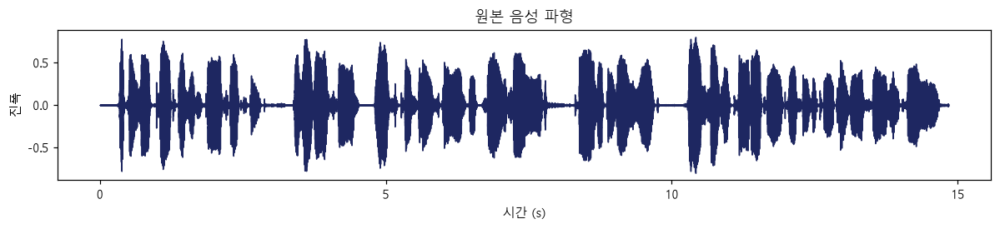

In [4]:
fig, ax = plt.subplots(figsize=(11, 2.6))
librosa.display.waveshow(y, sr=sr, ax=ax, color="#1E2761")
ax.set(title="원본 음성 파형", xlabel="시간 (s)", ylabel="진폭")
plt.tight_layout(); plt.show()
Audio(y, rate=sr)

### 공통 함수
- 실습 전반에서 반복 사용하는 함수 정의
- `add_noise`: 지정한 SNR(dB)로 백색 잡음 추가
- `frame_db`: 프레임별 RMS 레벨(dBFS) 계산
- `avg_spectrum_db`: 장구간 평균 스펙트럼(LTAS, dB) 계산

In [5]:
def add_noise(x, snr_db, seed=0):
    n = np.random.default_rng(seed).standard_normal(len(x))
    n *= np.sqrt(np.mean(x**2) / (np.mean(n**2) * 10**(snr_db / 10)))
    return x + n, n

def frame_db(x):
    rms = librosa.feature.rms(y=x, frame_length=FRAME, hop_length=HOP)[0]
    return librosa.amplitude_to_db(rms, ref=1.0, top_db=None)   # 0 dB = 최대 진폭 1.0

def avg_spectrum_db(x, frames=None):
    P = np.abs(librosa.stft(x, n_fft=N_FFT, hop_length=HOP))**2  # 파워 스펙트로그램
    if frames is not None:
        P = P[:, frames]                                          # 선택한 프레임만 사용
    return 10 * np.log10(P.mean(axis=1) + 1e-12)

freqs = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)               # 각 주파수 빈의 Hz 값
t_fr  = librosa.frames_to_time(np.arange(len(frame_db(y))), sr=SR, hop_length=HOP)

### 실험용 신호 생성 (실습 2 / 4 / 7에서 사용)
- 낭독 음성은 휴지(pause)가 짧음 → 게이트와 VAD 효과 관찰에 불리
- 처리 내용: 구(phrase) 단위 분할 → 구 사이 0.8 s 무음 삽입 / 앞뒤 1 s 무음 추가
- 반환 값: 실험용 신호 `y_t` / 프레임별 정답 레이블 `ref_t` (음성 True / 무음 False)
- 함수 내부 동작의 이해는 불필요 (VAD 실습에서 `librosa.effects.split` 별도 학습)

실험용 신호 길이 18.10 s / 음성 프레임 비율 75.6%


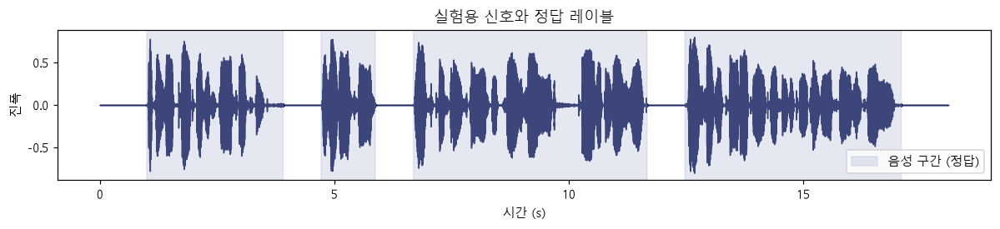

In [6]:
def make_test_signal(x, gap_s=0.8, edge_s=1.0):
    iv = librosa.effects.split(x, top_db=35, frame_length=FRAME, hop_length=HOP)
    phr = [list(iv[0])]
    for s, e in iv[1:]:                                  # 0.1 s 미만 간격은 하나의 구로 병합
        if s - phr[-1][1] < 0.1 * SR: phr[-1][1] = e
        else: phr.append([s, e])
    edge, gap = np.zeros(int(edge_s * SR)), np.zeros(int(gap_s * SR))
    parts, lab = [edge], [np.zeros(len(edge), bool)]
    for i, (s, e) in enumerate(phr):
        parts.append(x[s:e]); lab.append(np.ones(e - s, bool))
        z = gap if i < len(phr) - 1 else edge
        parts.append(z); lab.append(np.zeros(len(z), bool))
    sig, lab = np.concatenate(parts), np.concatenate(lab)
    n_fr = 1 + len(sig) // HOP
    ref = np.array([lab[min(i * HOP, len(lab) - 1)] for i in range(n_fr)])  # 프레임 중심 기준 레이블
    return sig, ref

y_t, ref_t = make_test_signal(y)
t_t = librosa.frames_to_time(np.arange(len(ref_t)), sr=SR, hop_length=HOP)
print(f"실험용 신호 길이 {len(y_t)/SR:.2f} s / 음성 프레임 비율 {ref_t.mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(11, 2.6))
librosa.display.waveshow(y_t, sr=SR, ax=ax, color="#1E2761")
ax.fill_between(t_t, -1, 1, where=ref_t, step="mid", color="#9AA6C8", alpha=.25, label="음성 구간 (정답)")
ax.set(ylim=(-np.abs(y_t).max()*1.1, np.abs(y_t).max()*1.1), title="실험용 신호와 정답 레이블",
       xlabel="시간 (s)", ylabel="진폭"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 실습 1. 프리엠퍼시스 (교재 3.1)

### 1-1. 평균 스펙트럼의 기울기 측정 (Figure 3.1 재현)
- 전체 프레임의 파워 평균 → 장구간 평균 스펙트럼(LTAS)
- `np.polyfit` 1차 직선 근사 → 기울기(dB/kHz) 산출
- 확인 사항: 교재 수치(약 −2 dB/kHz)와의 비교

평균 스펙트럼 기울기: -4.73 dB/kHz


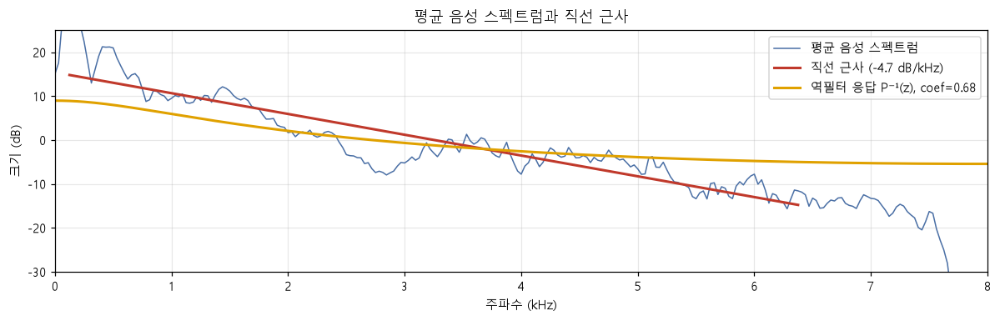

In [7]:
ltas = avg_spectrum_db(y)
ltas -= ltas[(freqs > 100) & (freqs < 6400)].mean()        # 평균 0 dB 기준 정렬
band = (freqs >= 100) & (freqs <= 6400)                     # 교재 그림과 동일 대역
slope, icpt = np.polyfit(freqs[band] / 1000, ltas[band], 1) # 1차 직선 근사
print(f"평균 스펙트럼 기울기: {slope:.2f} dB/kHz")

# 교재의 P^-1(z) : 프리엠퍼시스의 역필터 응답 (스펙트럼 추세 표현)
w, h = sps.freqz([1], [1, -0.68], worN=freqs, fs=SR)
inv_db = 20 * np.log10(np.abs(h))

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(freqs/1000, ltas, color="#4A6FA5", lw=1, label="평균 음성 스펙트럼")
ax.plot(freqs[band]/1000, slope*freqs[band]/1000 + icpt, color="#C0392B", lw=2,
        label=f"직선 근사 ({slope:.1f} dB/kHz)")
ax.plot(freqs/1000, inv_db - inv_db[band].mean(), color="#E0A100", lw=2,
        label="역필터 응답 P⁻¹(z), coef=0.68")
ax.set(xlim=(0, 8), ylim=(-30, 25), xlabel="주파수 (kHz)", ylabel="크기 (dB)",
       title="평균 음성 스펙트럼과 직선 근사")
ax.legend(loc="upper right"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 1-2. 프리엠퍼시스 필터의 주파수 응답 (Figure 3.2 재현)
- 필터 정의: P(z) = 1 − αz⁻¹ (α: 프리엠퍼시스 계수)
- `scipy.signal.freqz`로 크기 응답 계산
- 교재 조건: α = 0.68 / 샘플링 12.8 kHz
- 비교 조건: α = 0.97 (librosa 기본값 / 음성 인식 특징 추출에서 통용)

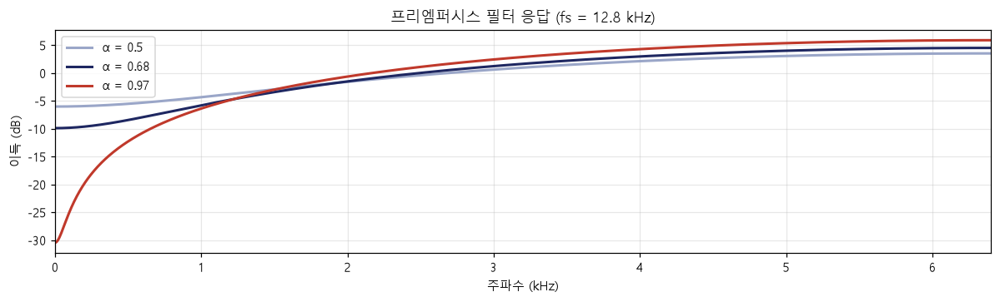

 0.0 kHz :   -9.9 dB
 1.0 kHz :   -5.8 dB
 2.0 kHz :   -1.5 dB
 4.0 kHz :   +3.0 dB
 6.0 kHz :   +4.5 dB
 6.4 kHz :   +4.5 dB


In [8]:
FS_BOOK = 12800
fig, ax = plt.subplots(figsize=(11, 3.4))
for coef, c in [(0.5, "#9AA6C8"), (0.68, "#1E2761"), (0.97, "#C0392B")]:
    w, h = sps.freqz([1, -coef], [1], worN=1024, fs=FS_BOOK)
    ax.plot(w/1000, 20*np.log10(np.abs(h)), color=c, lw=2, label=f"α = {coef}")
ax.set(xlim=(0, 6.4), xlabel="주파수 (kHz)", ylabel="이득 (dB)",
       title="프리엠퍼시스 필터 응답 (fs = 12.8 kHz)")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

# 교재 조건(α=0.68)의 주파수별 이득
for f in [0, 1000, 2000, 4000, 6000, 6400]:
    _, h = sps.freqz([1, -0.68], [1], worN=[f], fs=FS_BOOK)
    print(f"{f/1000:>4.1f} kHz : {20*np.log10(abs(h[0])):+6.1f} dB")

### 1-3. 프리엠퍼시스 적용 및 비교
- `librosa.effects.preemphasis(y, coef=α)` : y[n] − αy[n−1] 계산
- 비교 항목: 파형 / 스펙트로그램 / 청취 결과
- 관찰 포인트: 고주파 성분 강조 / 저주파(유성음 하모닉) 감쇠

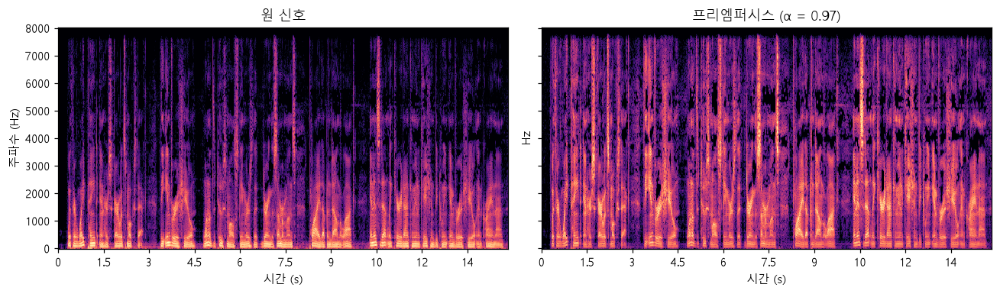

In [9]:
y_pre = librosa.effects.preemphasis(y, coef=0.97)

fig, axs = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, sig, ttl in [(axs[0], y, "원 신호"), (axs[1], y_pre, "프리엠퍼시스 (α = 0.97)")]:
    D = librosa.amplitude_to_db(np.abs(librosa.stft(sig, n_fft=N_FFT, hop_length=HOP)), ref=np.max)
    librosa.display.specshow(D, sr=SR, hop_length=HOP, x_axis="time", y_axis="hz",
                             ax=ax, cmap="magma", vmin=-80)
    ax.set(title=ttl, xlabel="시간 (s)")
axs[0].set_ylabel("주파수 (Hz)")
plt.tight_layout(); plt.show()
display(Audio(y, rate=sr), Audio(y_pre, rate=sr))

### 1-4. 계수(α)에 따른 스펙트럼 기울기 변화
- α 값을 바꿔 가며 평균 스펙트럼 기울기 재측정
- 기울기 0 dB/kHz 근처 → 스펙트럼 평탄화 달성

α = 0.00 → 기울기 -4.73 dB/kHz
α = 0.50 → 기울기 -3.13 dB/kHz
α = 0.68 → 기울기 -2.47 dB/kHz
α = 0.80 → 기울기 -2.01 dB/kHz
α = 0.90 → 기울기 -1.64 dB/kHz
α = 0.97 → 기울기 -1.44 dB/kHz


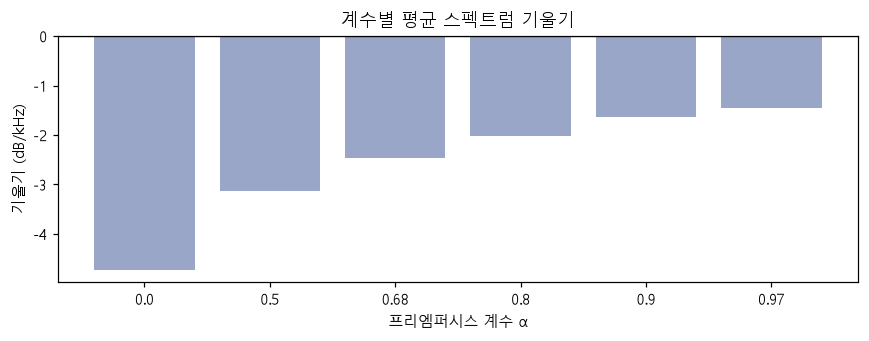

In [10]:
coefs = [0.0, 0.5, 0.68, 0.8, 0.9, 0.97]
slopes = []
for c in coefs:
    s = avg_spectrum_db(librosa.effects.preemphasis(y, coef=c))
    slopes.append(np.polyfit(freqs[band]/1000, s[band], 1)[0])
    print(f"α = {c:4.2f} → 기울기 {slopes[-1]:+5.2f} dB/kHz")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar([str(c) for c in coefs], slopes, color=["#9AA6C8"]*len(coefs))
ax.axhline(0, color="k", lw=.8)
ax.set(xlabel="프리엠퍼시스 계수 α", ylabel="기울기 (dB/kHz)", title="계수별 평균 스펙트럼 기울기")
plt.tight_layout(); plt.show()

### 1-5. 무성 마찰음에 대한 영향
- 프레임 분류: 영교차율(ZCR) 높음 + 에너지 충분 → 무성 마찰음 후보 / ZCR 낮음 + 에너지 큼 → 유성음
- 프리엠퍼시스 전후의 평균 스펙트럼 비교
- 관찰 포인트: 원래 고주파 에너지가 큰 마찰음의 추가 강조 → 과도한 프리엠퍼시스의 위험

마찰음 프레임 수: 60 / 유성음 프레임 수: 928


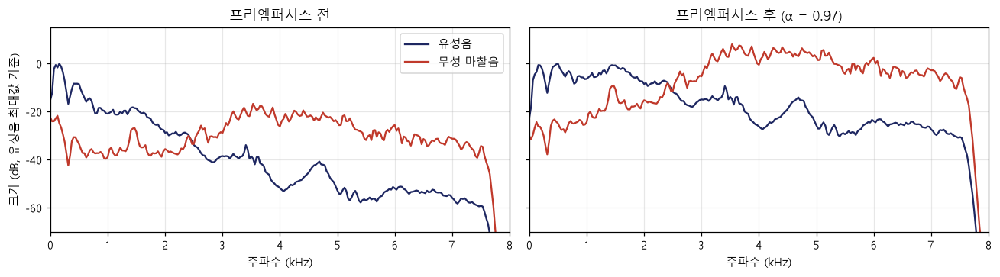

In [11]:
zcr = librosa.feature.zero_crossing_rate(y, frame_length=FRAME, hop_length=HOP)[0]
lv  = frame_db(y)
fric   = (zcr > 0.30) & (lv > lv.max() - 35)   # 무성 마찰음 후보 프레임
voiced = (zcr < 0.08) & (lv > lv.max() - 20)   # 유성음 프레임
print("마찰음 프레임 수:", fric.sum(), "/ 유성음 프레임 수:", voiced.sum())

fig, axs = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for ax, sig, ttl in [(axs[0], y, "프리엠퍼시스 전"), (axs[1], y_pre, "프리엠퍼시스 후 (α = 0.97)")]:
    v = avg_spectrum_db(sig, voiced); f_ = avg_spectrum_db(sig, fric)
    ref = v.max()
    ax.plot(freqs/1000, v - ref, color="#1E2761", lw=1.5, label="유성음")
    ax.plot(freqs/1000, f_ - ref, color="#C0392B", lw=1.5, label="무성 마찰음")
    ax.set(title=ttl, xlabel="주파수 (kHz)", xlim=(0, 8), ylim=(-70, 15)); ax.grid(alpha=.3)
axs[0].set_ylabel("크기 (dB, 유성음 최대값 기준)"); axs[0].legend()
plt.tight_layout(); plt.show()

### 1-6. 디엠퍼시스(de-emphasis)에 의한 복원
- 디엠퍼시스 필터: 1 / (1 − αz⁻¹) → 프리엠퍼시스의 역연산
- 음성 코딩: 송신 측 프리엠퍼시스 / 수신 측 디엠퍼시스 적용 구조
- 확인 사항: 복원 오차의 크기

In [12]:
y_rec = librosa.effects.deemphasis(y_pre, coef=0.97)
print(f"최대 복원 오차: {np.max(np.abs(y_rec - y)):.2e}")

최대 복원 오차: 5.59e-08


### 1-7. 고정소수점 관점의 정밀도 계산
- 1 bit ≈ 6.02 dB 관계 이용
- 저주파 대역(0~0.5 kHz)과 고주파 대역(5.5~6.5 kHz)의 평균 레벨 차이 → 고주파 성분이 잃는 유효 비트 수
- 교재 예시: 15 dB 차이 → 약 2.5 bit 손실 (15 bit 중 약 12 bit만 활용)

In [13]:
lo = (freqs <= 500); hi = (freqs >= 5500) & (freqs <= 6500)
for name, sig in [("원 신호", y), ("α=0.68", librosa.effects.preemphasis(y, coef=0.68)), ("α=0.97", y_pre)]:
    s = avg_spectrum_db(sig)
    gap = s[lo].mean() - s[hi].mean()
    print(f"{name:8s}: 저주파 − 고주파 = {gap:5.1f} dB → 고주파 유효 비트 손실 약 {gap/6.02:4.1f} bit")

원 신호    : 저주파 − 고주파 =  33.7 dB → 고주파 유효 비트 손실 약  5.6 bit
α=0.68  : 저주파 − 고주파 =  20.4 dB → 고주파 유효 비트 손실 약  3.4 bit
α=0.97  : 저주파 − 고주파 =   7.6 dB → 고주파 유효 비트 손실 약  1.3 bit


## 실습 2. 노이즈 게이트 (교재 3.2)

### 2-1. 잡음 추가 및 프레임 레벨 관찰
- 실험용 신호 `y_t`에 SNR 20 dB 백색 잡음 추가
- 프레임별 RMS 레벨(dBFS)과 임계값(threshold) 비교

잡음 바닥 -40.0 dBFS / 임계값 -34.0 dBFS


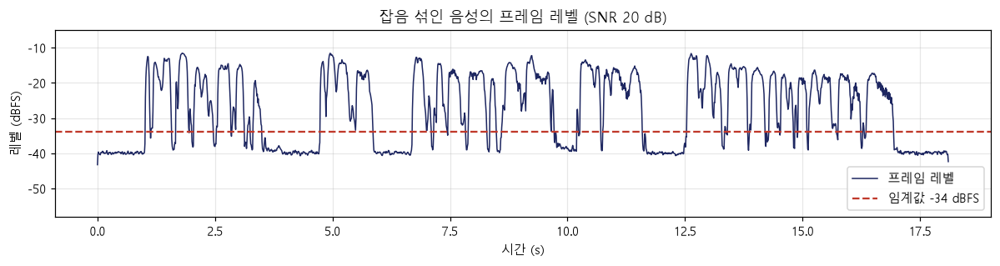

In [14]:
y_n20, _ = add_noise(y_t, 20)
lv_n = frame_db(y_n20)
THR = np.percentile(lv_n, 10) + 6        # 잡음 바닥(하위 10%) + 6 dB
print(f"잡음 바닥 {np.percentile(lv_n, 10):.1f} dBFS / 임계값 {THR:.1f} dBFS")

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(t_t, lv_n, color="#1E2761", lw=1, label="프레임 레벨")
ax.axhline(THR, color="#C0392B", ls="--", label=f"임계값 {THR:.0f} dBFS")
ax.set(xlabel="시간 (s)", ylabel="레벨 (dBFS)", ylim=(-58, -5), title="잡음 섞인 음성의 프레임 레벨 (SNR 20 dB)")
ax.legend(loc="lower right"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
Audio(y_n20, rate=sr)

### 2-2. 노이즈 게이트 구현
- 레벨 > 임계값 → 게이트 열림(이득 1) / 레벨 ≤ 임계값 → 닫힘(이득 floor)
- Attack: 열릴 때의 이득 변화 속도 / Release: 닫힐 때의 이득 변화 속도
- Hold: 임계값 이하로 떨어진 뒤 열림 상태를 유지하는 시간
- 1차 평활 계수: a = exp(−Δt / τ) (Δt: 프레임 간격, τ: 시정수)
- 단순화 사항: 이득을 프레임 단위(10 ms)로 계산 후 샘플 단위로 보간

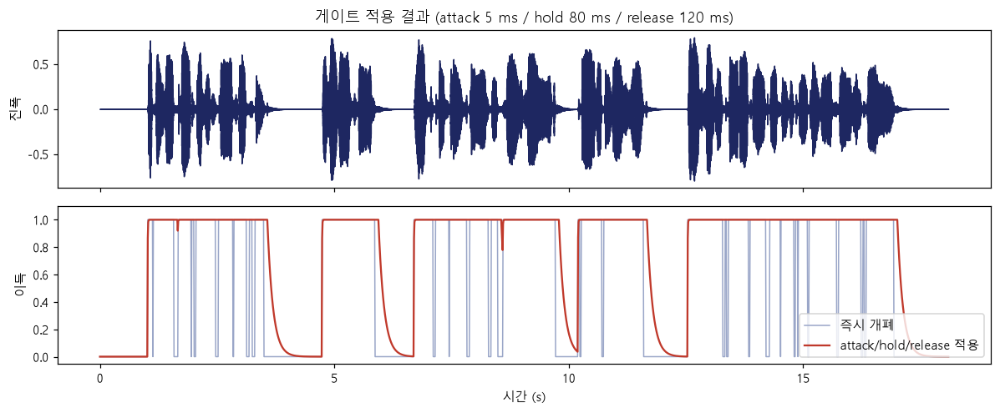

In [15]:
def noise_gate(x, thr_db, attack_ms=5, hold_ms=80, release_ms=120, floor_db=-60):
    lv = frame_db(x)
    dt = HOP / SR * 1000                       # 프레임 간격 (ms)
    a_att, a_rel = np.exp(-dt / attack_ms), np.exp(-dt / release_ms)
    hold_n = int(hold_ms / dt)                 # 유지 프레임 수
    floor = 10 ** (floor_db / 20)
    g = np.zeros(len(lv)); cur = floor; cnt = 0
    for i, l in enumerate(lv):
        if l > thr_db:   target, cnt = 1.0, hold_n   # 열림 + 유지 카운터 초기화
        elif cnt > 0:    target, cnt = 1.0, cnt - 1  # 유지 구간
        else:            target = floor              # 닫힘
        a = a_att if target > cur else a_rel
        cur = a * cur + (1 - a) * target              # 1차 평활
        g[i] = cur
    pos = librosa.frames_to_samples(np.arange(len(g)), hop_length=HOP)
    return x * np.interp(np.arange(len(x)), pos, g), g

y_gate_hard, g_hard = noise_gate(y_n20, THR, attack_ms=0.01, hold_ms=0, release_ms=0.01)
y_gate, g_soft      = noise_gate(y_n20, THR)

fig, axs = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)
librosa.display.waveshow(y_gate, sr=sr, ax=axs[0], color="#1E2761")
axs[0].set(title="게이트 적용 결과 (attack 5 ms / hold 80 ms / release 120 ms)", ylabel="진폭", xlabel="")
axs[1].plot(t_t, g_hard, color="#9AA6C8", lw=1, label="즉시 개폐")
axs[1].plot(t_t, g_soft, color="#C0392B", lw=1.5, label="attack/hold/release 적용")
axs[1].set(xlabel="시간 (s)", ylabel="이득", ylim=(-0.05, 1.1)); axs[1].legend(loc="lower right")
plt.tight_layout(); plt.show()
display(Audio(y_gate_hard, rate=sr), Audio(y_gate, rate=sr))

### 2-3. 임계값에 따른 결과 비교
- 임계값 상향 → 배경 잡음 제거 효과 증가 / 약한 자음과 어말 성분 손실 증가
- 측정 항목: 열림 프레임 비율 / 원 음성 에너지 보존율

In [16]:
for d in [0, 6, 12, 18]:
    yg, g = noise_gate(y_n20, THR + d)
    pos = librosa.frames_to_samples(np.arange(len(g)), hop_length=HOP)
    keep = np.sum((y_t * np.interp(np.arange(len(y_t)), pos, g))**2) / np.sum(y_t**2)
    miss = np.mean(g[ref_t] < 0.5) * 100                 # 닫혀 버린 음성 프레임 비율
    print(f"임계값 {THR + d:6.1f} dBFS : 열림 비율 {np.mean(g > 0.5)*100:5.1f}% / 음성 프레임 차단 {miss:5.1f}% / 음성 에너지 보존 {keep*100:5.1f}%")

임계값  -34.0 dBFS : 열림 비율  73.1% / 음성 프레임 차단   5.0% / 음성 에너지 보존 100.0%
임계값  -28.0 dBFS : 열림 비율  72.2% / 음성 프레임 차단   5.9% / 음성 에너지 보존  99.9%
임계값  -22.0 dBFS : 열림 비율  67.8% / 음성 프레임 차단  11.1% / 음성 에너지 보존  99.1%
임계값  -16.0 dBFS : 열림 비율  33.1% / 음성 프레임 차단  56.2% / 음성 에너지 보존  68.0%


### 2-4. librosa.effects.trim — 앞뒤 무음 제거
- 최대 레벨 대비 `top_db` 이하 구간을 신호 앞뒤에서 제거
- 게이트와의 차이: 신호 중간의 무음은 그대로 유지

In [17]:
y_trim, idx = librosa.effects.trim(y_n20, top_db=25, frame_length=FRAME, hop_length=HOP)
print(f"원 길이 {len(y_n20)/sr:.2f} s → trim 후 {len(y_trim)/sr:.2f} s (구간 {idx[0]/sr:.2f}–{idx[1]/sr:.2f} s)")

원 길이 18.10 s → trim 후 15.93 s (구간 1.02–16.95 s)


## 실습 3. 동적 범위 압축 (교재 3.3)

### 3-1. 정적 압축 곡선
- 입력 레벨 ≤ 임계값 T → 그대로 통과
- 입력 레벨 > T → 출력 = T + (입력 − T) / R (R: 압축비)
- R = ∞ → 리미터(limiter)

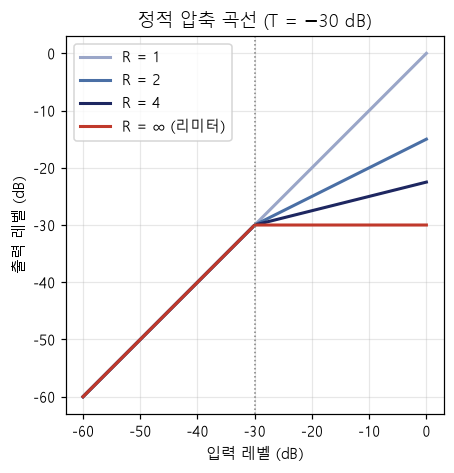

In [18]:
def comp_curve(in_db, thr_db=-30, ratio=4):
    return np.where(in_db > thr_db, thr_db + (in_db - thr_db) / ratio, in_db)

L = np.linspace(-60, 0, 200)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
for r, c in [(1, "#9AA6C8"), (2, "#4A6FA5"), (4, "#1E2761"), (1e9, "#C0392B")]:
    ax.plot(L, comp_curve(L, -30, r), color=c, lw=2, label="R = ∞ (리미터)" if r > 100 else f"R = {r}")
ax.axvline(-30, color="gray", ls=":", lw=1)
ax.set(xlabel="입력 레벨 (dB)", ylabel="출력 레벨 (dB)", title="정적 압축 곡선 (T = −30 dB)", aspect="equal")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 3-2. 압축기 구현
- 처리 순서: 프레임 레벨 측정 → 정적 곡선으로 목표 이득 계산 → attack/release 평활 → makeup gain 적용
- Attack: 이득을 줄이는 속도(큰 소리 대응) / Release: 이득을 되돌리는 속도

In [19]:
def compressor(x, thr_db=-40, ratio=4, attack_ms=10, release_ms=150, makeup_db=0):
    lv = frame_db(x)
    target = np.minimum(0, comp_curve(lv, thr_db, ratio) - lv)   # 목표 이득 감소량 (dB, ≤ 0)
    dt = HOP / SR * 1000
    a_att, a_rel = np.exp(-dt / attack_ms), np.exp(-dt / release_ms)
    g = np.zeros_like(target); cur = 0.0
    for i, tg in enumerate(target):
        a = a_att if tg < cur else a_rel           # 감소 방향: attack / 복귀 방향: release
        cur = a * cur + (1 - a) * tg
        g[i] = cur
    g_db = g + makeup_db
    pos = librosa.frames_to_samples(np.arange(len(g)), hop_length=HOP)
    return x * 10 ** (np.interp(np.arange(len(x)), pos, g_db) / 20), g_db

### 3-3. 화자 간 음량 차이 보정 실험
- 실험 신호: 전반부 원 음량 / 후반부 −20 dB (원거리 화자 상황 모사)
- 비교 대상: 압축기 / `librosa.util.normalize`(최대값 정규화)
- 측정 항목: 전반부와 후반부의 음성 구간 평균 레벨 차이

입력        : 전반부  -20.6 dB / 후반부  -38.6 dB / 차이  18.0 dB
최대값 정규화   : 전반부  -19.3 dB / 후반부  -37.3 dB / 차이  18.0 dB
압축기       : 전반부  -19.8 dB / 후반부  -24.8 dB / 차이   5.1 dB


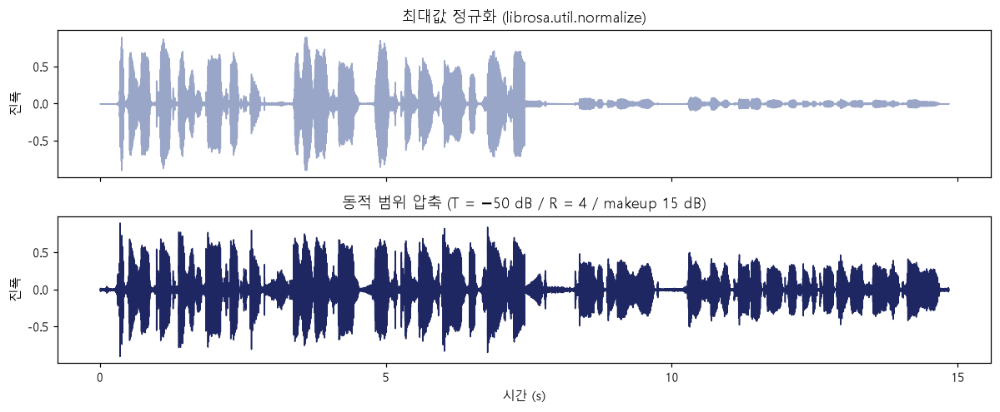

In [20]:
mid = len(y) // 2
y_var = y.copy(); y_var[mid:] *= 0.1                         # 후반부 −20 dB
y_cmp, g_db = compressor(y_var, thr_db=-50, ratio=4, makeup_db=15)
y_cmp = y_cmp / np.max(np.abs(y_cmp)) * 0.9                  # 최종 최대값 0.9로 맞춤
y_nrm = librosa.util.normalize(y_var) * 0.9                  # 최대값 정규화만 적용

def half_levels(x):
    lv = frame_db(x); n = len(lv) // 2
    a, b = lv[:n], lv[n:]
    return a[a > a.max() - 25].mean(), b[b > b.max() - 25].mean()

for name, sig in [("입력", y_var), ("최대값 정규화", y_nrm), ("압축기", y_cmp)]:
    a, b = half_levels(sig)
    print(f"{name:10s}: 전반부 {a:6.1f} dB / 후반부 {b:6.1f} dB / 차이 {a-b:5.1f} dB")

fig, axs = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True, sharey=True)
librosa.display.waveshow(y_nrm, sr=sr, ax=axs[0], color="#9AA6C8")
axs[0].set(title="최대값 정규화 (librosa.util.normalize)", xlabel="", ylabel="진폭")
librosa.display.waveshow(y_cmp, sr=sr, ax=axs[1], color="#1E2761")
axs[1].set(title="동적 범위 압축 (T = −50 dB / R = 4 / makeup 15 dB)", xlabel="시간 (s)", ylabel="진폭")
plt.tight_layout(); plt.show()
display(Audio(y_nrm, rate=sr), Audio(y_cmp, rate=sr))

### 3-4. 참고: μ-law 압신(companding)
- `librosa.mu_compress` : 샘플 단위 순간 압축 → 시정수(attack/release) 없음
- 용도: 양자화 잡음의 균등화(전화망 G.711 / 신경망 보코더 출력 표현)
- 동적 범위 압축과의 차이: 음량 균일화가 아닌 양자화 효율 개선 목적

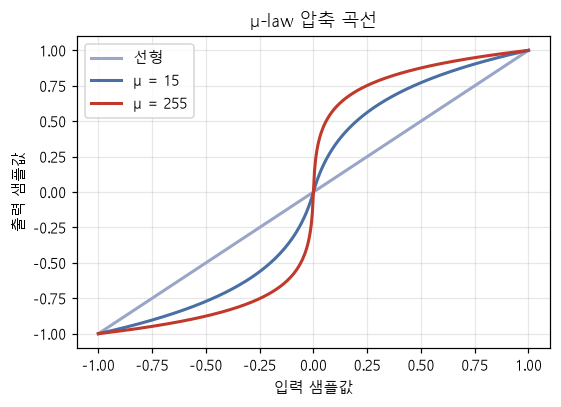

In [21]:
x = np.linspace(-1, 1, 401)
fig, ax = plt.subplots(figsize=(5.2, 3.8))
for mu, c in [(0, "#9AA6C8"), (15, "#4A6FA5"), (255, "#C0392B")]:
    yy = x if mu == 0 else librosa.mu_compress(x, mu=mu, quantize=False)
    ax.plot(x, yy, color=c, lw=2, label="선형" if mu == 0 else f"μ = {mu}")
ax.set(xlabel="입력 샘플값", ylabel="출력 샘플값", title="μ-law 압축 곡선"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 실습 4. 음성 활동 검출, VAD (교재 3.4)

### 4-1. VAD 특징 관찰
- 프레임 에너지(dBFS): 음성 구간에서 큼
- 영교차율(ZCR): 무성음/잡음에서 큼 / 유성음에서 작음
- 스펙트럼 평탄도(spectral flatness): 백색 잡음 ≈ 1 / 음성(하모닉 구조) ≈ 0에 근접

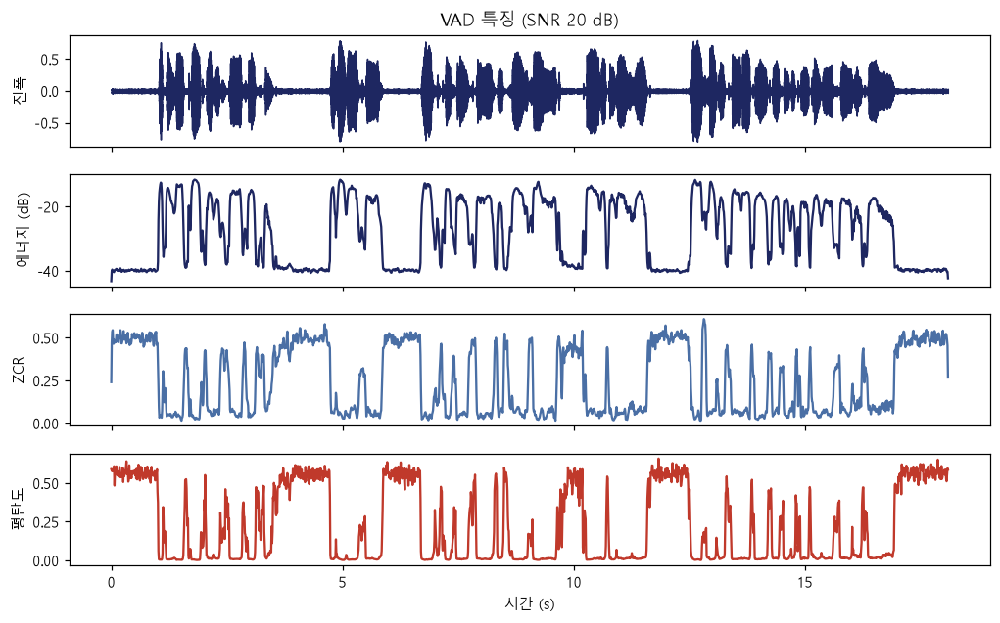

In [22]:
zcr_n  = librosa.feature.zero_crossing_rate(y_n20, frame_length=FRAME, hop_length=HOP)[0]
flat_n = librosa.feature.spectral_flatness(y=y_n20, n_fft=N_FFT, hop_length=HOP)[0]

fig, axs = plt.subplots(4, 1, figsize=(11, 6.4), sharex=True)
librosa.display.waveshow(y_n20, sr=sr, ax=axs[0], color="#1E2761"); axs[0].set(ylabel="진폭", xlabel="")
axs[1].plot(t_t, lv_n, color="#1E2761");  axs[1].set(ylabel="에너지 (dB)")
axs[2].plot(t_t, zcr_n, color="#4A6FA5"); axs[2].set(ylabel="ZCR")
axs[3].plot(t_t, flat_n, color="#C0392B"); axs[3].set(ylabel="평탄도", xlabel="시간 (s)")
axs[0].set_title("VAD 특징 (SNR 20 dB)")
plt.tight_layout(); plt.show()

### 4-2. 에너지 기반 VAD 구현
- 잡음 바닥 추정: 프레임 레벨의 하위 10% 백분위수
- 판정 규칙: 레벨 > 잡음 바닥 + margin(6 dB) → 음성
- 판정 평활 ①: 200 ms 이하의 짧은 공백 메우기 (`binary_closing`)
- 판정 평활 ②: 고립된 짧은 오판정 제거 (`binary_opening`)
- 행오버(hangover): 음성 구간 앞뒤 50 ms 연장 → 약한 어두/어말 자음 보호 (`binary_dilation`)
- 평가용 정답: 실험용 신호 생성 시 얻은 `ref_t`

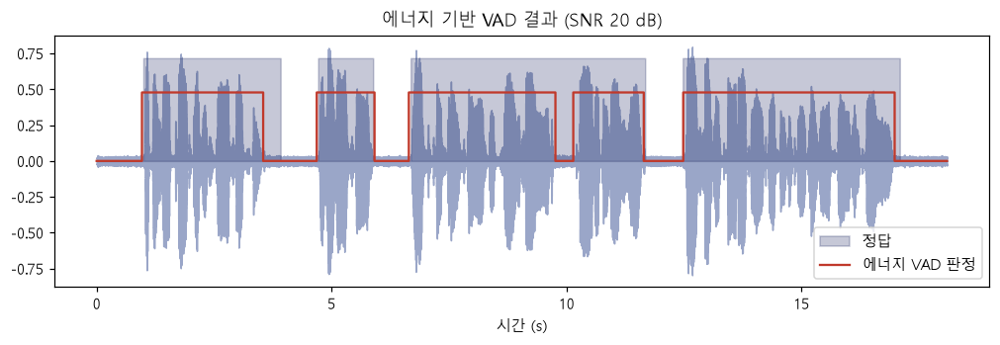

In [23]:
def energy_vad(x, margin_db=6, gap_fr=21, hang_fr=5):
    lv = frame_db(x)
    floor = np.percentile(lv, 10)                                    # 잡음 바닥
    v = lv > floor + margin_db                                       # 1차 판정
    v = ndi.binary_closing(v, structure=np.ones(gap_fr))            # 짧은 공백 메우기
    v = ndi.binary_opening(v, structure=np.ones(3))                 # 고립 오판정 제거
    return ndi.binary_dilation(v, structure=np.ones(2 * hang_fr + 1))  # 행오버

ref = ref_t                                            # 정답 레이블
hyp = energy_vad(y_n20)

fig, ax = plt.subplots(figsize=(11, 3.0))
librosa.display.waveshow(y_n20, sr=sr, ax=ax, color="#9AA6C8")
ax.fill_between(t_t, 0, ref * 0.9 * np.abs(y_n20).max(), step="mid", color="#1E2761", alpha=.25, label="정답")
ax.step(t_t, hyp * 0.6 * np.abs(y_n20).max(), where="mid", color="#C0392B", lw=1.5, label="에너지 VAD 판정")
ax.set(xlabel="시간 (s)", title="에너지 기반 VAD 결과 (SNR 20 dB)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 4-3. librosa.effects.split — 구간 단위 분할
- 최대 레벨 대비 `top_db` 이내 구간을 음성 구간 [시작, 끝] 샘플 인덱스로 반환
- 활용: 긴 녹음의 발화 단위 분할 / 무음 구간 제거

In [24]:
intervals = librosa.effects.split(y_n20, top_db=25, frame_length=FRAME, hop_length=HOP)
for s, e in intervals[:8]:
    print(f"{s/sr:6.2f} – {e/sr:6.2f} s")
print("검출 구간 수:", len(intervals))

def intervals_to_frames(iv, n):
    lab = np.zeros(n, bool)
    for s, e in iv:
        lab[s // HOP : e // HOP + 1] = True
    return lab

  1.02 –   1.59 s
  1.67 –   2.01 s
  2.05 –   2.48 s
  2.53 –   3.13 s
  3.19 –   3.26 s
  3.31 –   3.50 s
  3.56 –   3.58 s
  4.74 –   5.87 s
검출 구간 수: 25


### 4-4. SNR에 따른 성능 평가
- FAR(False Alarm Rate): 비음성 프레임을 음성으로 판정한 비율
- MDR(Miss Detection Rate): 음성 프레임을 비음성으로 판정한 비율
- 관찰 포인트: SNR 저하에 따른 오류 증가 / 두 오류 간의 상충 관계
- 비교 포인트: 최대 레벨 기준 고정 임계값(`split`) vs 잡음 바닥 기준 적응 임계값(에너지 VAD)

 SNR | 에너지VAD FAR  MDR | split FAR  MDR
 20dB |        2.9   6.6 |      0.0  11.8
 10dB |        2.0  10.0 |    100.0   0.0
  5dB |        1.4  18.0 |    100.0   0.0
  0dB |        0.0  68.0 |    100.0   0.0


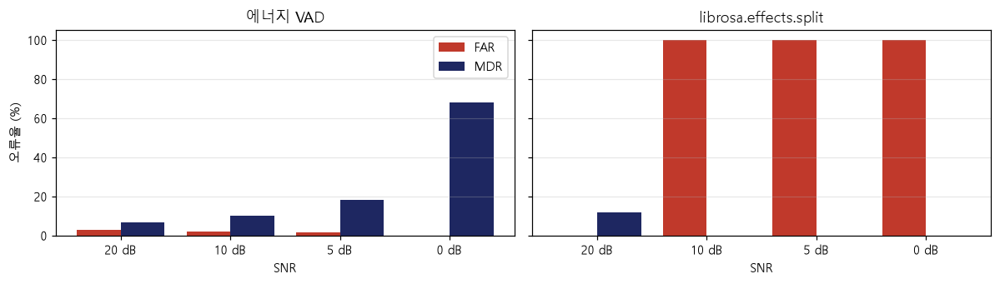

In [25]:
def far_mdr(ref, hyp):
    return np.mean(hyp[~ref]) * 100, np.mean(~hyp[ref]) * 100

rows = []
for snr in [20, 10, 5, 0]:
    yn, _ = add_noise(y_t, snr)
    h1 = energy_vad(yn)
    h2 = intervals_to_frames(librosa.effects.split(yn, top_db=25, frame_length=FRAME, hop_length=HOP), len(ref))
    rows.append((snr, *far_mdr(ref, h1), *far_mdr(ref, h2)))
print(" SNR | 에너지VAD FAR  MDR | split FAR  MDR")
for r in rows:
    print(f"{r[0]:3d}dB |      {r[1]:5.1f} {r[2]:5.1f} |    {r[3]:5.1f} {r[4]:5.1f}")

fig, axs = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
snrs = [f"{r[0]} dB" for r in rows]
for ax, i, ttl in [(axs[0], 1, "에너지 VAD"), (axs[1], 3, "librosa.effects.split")]:
    xx = np.arange(len(rows))
    ax.bar(xx - .2, [r[i] for r in rows], .4, color="#C0392B", label="FAR")
    ax.bar(xx + .2, [r[i+1] for r in rows], .4, color="#1E2761", label="MDR")
    ax.set(xticks=xx, xticklabels=snrs, title=ttl, xlabel="SNR"); ax.grid(axis="y", alpha=.3)
axs[0].set_ylabel("오류율 (%)"); axs[0].legend()
plt.tight_layout(); plt.show()

## 실습 5. 성도 길이 정규화, VTLN (교재 3.5)

### 5-1. 성도 길이 차이의 모사
- `librosa.effects.pitch_shift` : 길이 유지 + 전체 주파수 성분을 같은 비율로 이동
- +3 반음 이동 → 주파수 배율 α = 2^(3/12) ≈ 1.19 (성도가 짧은 화자의 모사)
- 주의 사항: 실제 화자 차이는 F0와 포먼트가 독립적으로 변화 / 본 실습은 단순화 모델

실제 주파수 배율 α = 1.189


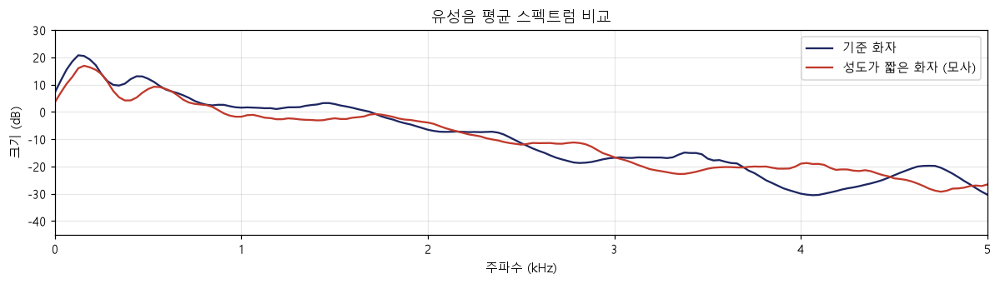

In [26]:
ALPHA_TRUE = 2 ** (3 / 12)
y_short = librosa.effects.pitch_shift(y, sr=sr, n_steps=3)       # '성도가 짧은 화자' 모사
print(f"실제 주파수 배율 α = {ALPHA_TRUE:.3f}")

v = voiced                                                        # 실습 1-5의 유성음 프레임
sm = lambda s: np.convolve(s, np.ones(5)/5, mode="same")          # 보기 좋게 평활
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(freqs/1000, sm(avg_spectrum_db(y, v)), color="#1E2761", lw=1.5, label="기준 화자")
ax.plot(freqs/1000, sm(avg_spectrum_db(y_short, v)), color="#C0392B", lw=1.5, label="성도가 짧은 화자 (모사)")
ax.set(xlim=(0, 5), ylim=(-45, 30), xlabel="주파수 (kHz)", ylabel="크기 (dB)", title="유성음 평균 스펙트럼 비교")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
display(Audio(y, rate=sr), Audio(y_short, rate=sr))

### 5-2. 주파수 워핑 구현
- 워핑 정의: S_w(f) = S(αf) → 주파수축을 α 배율로 재조정
- `scipy.interpolate.interp1d`로 주파수축 보간
- 워핑 후 멜 스펙트로그램(40 밴드) 계산

In [27]:
mel_fb = librosa.filters.mel(sr=SR, n_fft=N_FFT, n_mels=40)

def warp_power(P, alpha):
    f = interp1d(freqs, P, axis=0, bounds_error=False, fill_value=0.0)
    return f(np.clip(freqs * alpha, 0, freqs[-1]))      # αf 위치의 값을 f 위치로 이동

def logmel(P):
    return np.log(mel_fb @ P + 1e-8)

P_ref   = np.abs(librosa.stft(y,       n_fft=N_FFT, hop_length=HOP))**2
P_short = np.abs(librosa.stft(y_short, n_fft=N_FFT, hop_length=HOP))**2

### 5-3. 워핑 인수 탐색
- 후보 α를 0.80~1.40 범위에서 0.01 간격으로 시험
- 기준: 기준 화자의 로그 멜 스펙트럼과의 평균 제곱 거리 최소화
- 실제 VTLN: 음향 모델에 대한 우도 최대화(MLE)로 α 선택 / 본 실습은 거리 최소화로 단순화

추정 α = 1.16 / 실제 α = 1.189


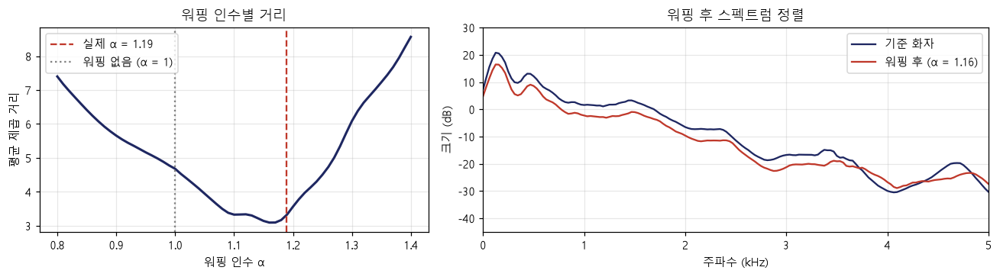

In [28]:
lv_c = frame_db(y)
act = lv_c > lv_c.max() - 30                                   # 음성 프레임만 사용
L_ref = logmel(P_ref)[:, act]
alphas = np.round(np.arange(0.80, 1.41, 0.01), 2)
dist = [np.mean((logmel(warp_power(P_short, a))[:, act] - L_ref) ** 2) for a in alphas]
a_hat = alphas[int(np.argmin(dist))]
print(f"추정 α = {a_hat:.2f} / 실제 α = {ALPHA_TRUE:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [1, 1.3]})
axs[0].plot(alphas, dist, color="#1E2761", lw=2)
axs[0].axvline(ALPHA_TRUE, color="#C0392B", ls="--", label=f"실제 α = {ALPHA_TRUE:.2f}")
axs[0].axvline(1.0, color="gray", ls=":", label="워핑 없음 (α = 1)")
axs[0].set(xlabel="워핑 인수 α", ylabel="평균 제곱 거리", title="워핑 인수별 거리"); axs[0].legend()
axs[1].plot(freqs/1000, sm(avg_spectrum_db(y, v)), color="#1E2761", lw=1.5, label="기준 화자")
P_w = warp_power(P_short, a_hat)
axs[1].plot(freqs/1000, sm(10*np.log10(P_w[:, v].mean(axis=1) + 1e-12)), color="#C0392B", lw=1.5,
            label=f"워핑 후 (α = {a_hat:.2f})")
axs[1].set(xlim=(0, 5), ylim=(-45, 30), xlabel="주파수 (kHz)", ylabel="크기 (dB)", title="워핑 후 스펙트럼 정렬"); axs[1].legend()
for a in axs: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 실습 6. 음성 향상 (교재 3.6)

### 6-1. 잡음 전력 스펙트럼 추정 — 최소 통계법(단순화)
- 실험 신호: SNR 5 dB 백색 잡음 혼합
- 원리: 음성 구간에서도 각 주파수의 전력은 잠시 잡음 수준까지 하강 → 일정 시간 창 내 최소값 = 잡음 추정
- 처리 순서: 시간 방향 평활(100 ms) → 1.5 s 창 최소값 → 편향 보정 계수(2.5) 곱셈
- 편향 보정 필요성: 최소값은 평균보다 항상 작음 → 과소 추정 / 보정 계수는 평활 길이와 창 길이에 따라 달라지는 경험값
- 검증: 실제 추가한 잡음의 전력 스펙트럼과 비교

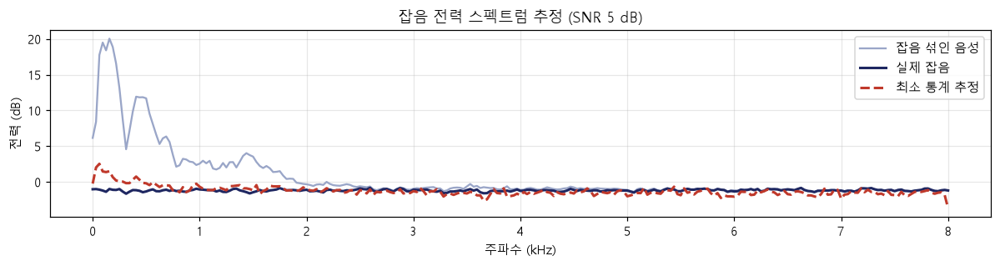

In [29]:
y_n5, n5 = add_noise(y, 5)
X  = librosa.stft(y_n5, n_fft=N_FFT, hop_length=HOP)
P  = np.abs(X) ** 2
Ps = ndi.uniform_filter1d(P, size=10, axis=1)                 # 시간 방향 평활 (100 ms)
N_est = ndi.minimum_filter1d(Ps, size=150, axis=1) * 2.5      # 1.5 s 창 최소값 × 편향 보정
N_true = np.abs(librosa.stft(n5, n_fft=N_FFT, hop_length=HOP)) ** 2

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(freqs/1000, 10*np.log10(P.mean(axis=1)), color="#9AA6C8", label="잡음 섞인 음성")
ax.plot(freqs/1000, 10*np.log10(N_true.mean(axis=1)), color="#1E2761", lw=2, label="실제 잡음")
ax.plot(freqs/1000, 10*np.log10(N_est.mean(axis=1)), color="#C0392B", lw=2, ls="--", label="최소 통계 추정")
ax.set(xlabel="주파수 (kHz)", ylabel="전력 (dB)", title="잡음 전력 스펙트럼 추정 (SNR 5 dB)")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 6-2. 스펙트럼 차감법과 위너 필터
- 스펙트럼 차감법(Boll, 1979): |Ŝ|² = max(|X|² − βN̂, floor×|X|²) / 위상은 잡음 섞인 신호의 위상 재사용
- 위너 필터: 사전 SNR ξ = max(|X|²/N̂ − 1, ξ_min) → 이득 G = ξ / (1 + ξ)
- β: 과차감 계수 / floor와 ξ_min: 음악 잡음(musical noise) 억제용 하한

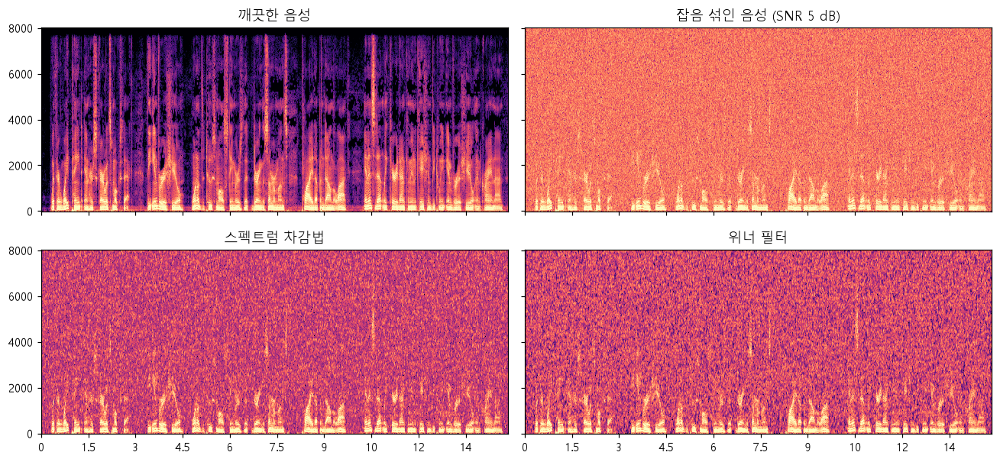

In [30]:
def spectral_subtraction(X, N, beta=2.0, floor=0.02):
    P = np.abs(X) ** 2
    P_hat = np.maximum(P - beta * N, floor * P)
    return np.sqrt(P_hat) * np.exp(1j * np.angle(X))

def wiener(X, N, xi_min_db=-15):
    xi = np.abs(X)**2 / (N + 1e-12) - 1                 # 사후 SNR − 1
    xi = np.maximum(xi, 10 ** (xi_min_db / 10))          # 사전 SNR 하한
    return X * xi / (1 + xi)

y_ss = librosa.istft(spectral_subtraction(X, N_est), hop_length=HOP, length=len(y))
y_wf = librosa.istft(wiener(X, N_est), hop_length=HOP, length=len(y))

fig, axs = plt.subplots(2, 2, figsize=(12, 5.6), sharex=True, sharey=True)
for ax, sig, ttl in zip(axs.ravel(), [y, y_n5, y_ss, y_wf],
                        ["깨끗한 음성", "잡음 섞인 음성 (SNR 5 dB)", "스펙트럼 차감법", "위너 필터"]):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(sig, n_fft=N_FFT, hop_length=HOP)), ref=1.0, top_db=None)
    librosa.display.specshow(D, sr=SR, hop_length=HOP, x_axis="time", y_axis="hz", ax=ax,
                             cmap="magma", vmin=-60, vmax=20)
    ax.set(title=ttl, xlabel="", ylabel="")
plt.tight_layout(); plt.show()
display(Audio(y_n5, rate=sr), Audio(y_ss, rate=sr), Audio(y_wf, rate=sr))

### 6-3. 객관적 평가
- SNR / 구간 SNR(segSNR): 깨끗한 음성 대비 오차 전력 기준
- STOI: 명료도 예측 (0~1) / PESQ(협대역 모드): 지각 음질 (−0.5~4.5) — 선택 설치 패키지 필요
- 관찰 포인트: SNR 개선과 지각 지표 개선의 불일치 가능성

In [31]:
def snr(clean, est):
    return 10 * np.log10(np.sum(clean**2) / np.sum((clean - est)**2))

def seg_snr(clean, est):
    c = librosa.util.frame(clean, frame_length=FRAME, hop_length=HOP)
    e = librosa.util.frame(est,   frame_length=FRAME, hop_length=HOP)
    s = 10 * np.log10(np.sum(c**2, 0) / (np.sum((c - e)**2, 0) + 1e-12) + 1e-12)
    return np.mean(np.clip(s, -10, 35)[np.sum(c**2, 0) > 1e-4])

try:
    from pystoi import stoi; from pesq import pesq; HAS_METRIC = True
except ImportError:
    HAS_METRIC = False

print("방법          SNR   segSNR" + ("   STOI   PESQ" if HAS_METRIC else ""))
for name, sig in [("잡음 섞인 음성", y_n5), ("스펙트럼 차감", y_ss), ("위너 필터", y_wf)]:
    line = f"{name:10s} {snr(y, sig):6.2f} {seg_snr(y, sig):7.2f}"
    if HAS_METRIC:
        line += f" {stoi(y, sig, SR):6.3f} {pesq(SR, y, sig, 'nb'):6.2f}"
    print(line)

방법          SNR   segSNR
잡음 섞인 음성     5.00    0.49
스펙트럼 차감     11.40    5.40
위너 필터       10.53    4.70


### 6-4. 과차감 계수 β의 영향
- β 증가 → 잡음 제거량 증가 / 음성 왜곡 및 음악 잡음 증가
- 청취 비교를 통한 상충 관계 확인

In [32]:
outs = []
for beta in [1.0, 2.0, 4.0, 8.0]:
    yb = librosa.istft(spectral_subtraction(X, N_est, beta=beta), hop_length=HOP, length=len(y))
    outs.append(yb)
    print(f"β = {beta:3.1f} : SNR {snr(y, yb):6.2f} dB / segSNR {seg_snr(y, yb):6.2f} dB")
display(*[Audio(o, rate=sr) for o in outs])

β = 1.0 : SNR   8.83 dB / segSNR   3.38 dB
β = 2.0 : SNR  11.40 dB / segSNR   5.40 dB
β = 4.0 : SNR  12.92 dB / segSNR   6.91 dB
β = 8.0 : SNR  12.00 dB / segSNR   6.51 dB


## 실습 7. 전처리 파이프라인 종합

- 처리 순서: ① 음성 향상(위너 필터) → ② 노이즈 게이트 → ③ 앞뒤 무음 제거 → ④ 동적 범위 압축 → ⑤ 정규화 → ⑥ 프리엠퍼시스
- 게이트를 압축보다 앞에 두는 이유: 압축의 makeup gain이 잔여 잡음까지 함께 증폭
- 프리엠퍼시스 위치: 특징 추출(MFCC 등) 직전 / 잡음 추정보다 앞에 두면 잡음 스펙트럼 형태가 바뀜
- 입력: 실험용 신호의 후반부 −15 dB 감쇠(원거리 화자) + SNR 20 dB 잡음 혼합

입력          : 전/후반부 레벨 차이  16.1 dB / 잡음 바닥(하위 5%)  -42.9 dBFS
① 음성 향상     : 전/후반부 레벨 차이  19.3 dB / 잡음 바닥(하위 5%)  -50.3 dBFS
② 노이즈 게이트   : 전/후반부 레벨 차이  16.0 dB / 잡음 바닥(하위 5%) -100.0 dBFS
③ 앞뒤 무음 제거  : 전/후반부 레벨 차이  16.0 dB / 잡음 바닥(하위 5%)  -85.6 dBFS
④ 동적 범위 압축  : 전/후반부 레벨 차이   3.1 dB / 잡음 바닥(하위 5%)  -73.9 dBFS
⑤ 정규화       : 전/후반부 레벨 차이   3.1 dB / 잡음 바닥(하위 5%)  -62.4 dBFS


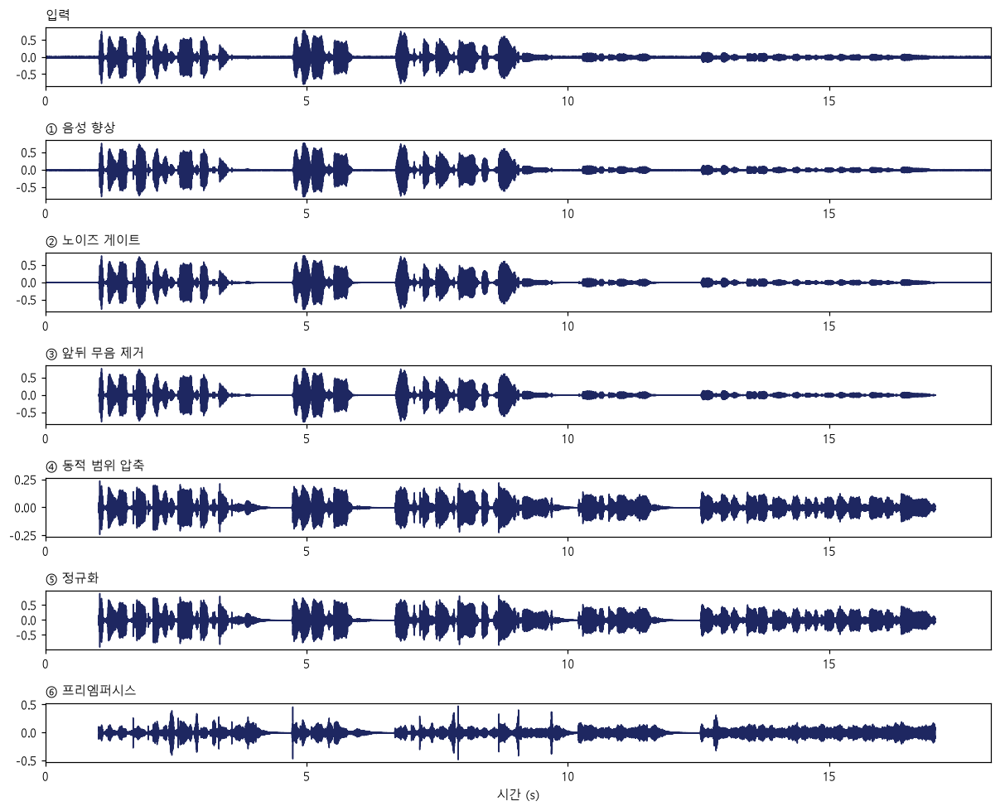

In [33]:
def preprocess(x):
    X = librosa.stft(x, n_fft=N_FFT, hop_length=HOP)
    Ps = ndi.uniform_filter1d(np.abs(X)**2, size=10, axis=1)
    N = ndi.minimum_filter1d(Ps, size=150, axis=1) * 2.5
    x1 = librosa.istft(wiener(X, N), hop_length=HOP, length=len(x))           # ① 음성 향상
    x2, _ = noise_gate(x1, np.percentile(frame_db(x1), 10) + 6)                # ② 노이즈 게이트
    x3, idx = librosa.effects.trim(x2, top_db=40, frame_length=FRAME, hop_length=HOP)  # ③ 무음 제거
    x4, _ = compressor(x3, thr_db=-45, ratio=4, makeup_db=12)                  # ④ 동적 범위 압축
    x5 = librosa.util.normalize(x4) * 0.9                                      # ⑤ 정규화
    x6 = librosa.effects.preemphasis(x5, coef=0.97)                            # ⑥ 프리엠퍼시스
    return [x1, x2, x3, x4, x5, x6], idx[0]

y_tv = y_t.copy(); y_tv[len(y_t)//2:] *= 0.18          # 후반부 −15 dB (원거리 화자)
x_in, _ = add_noise(y_tv, 20)
stages, start = preprocess(x_in)

names = ["입력", "① 음성 향상", "② 노이즈 게이트", "③ 앞뒤 무음 제거",
         "④ 동적 범위 압축", "⑤ 정규화", "⑥ 프리엠퍼시스"]
sigs = [x_in] + stages
for nm, sig in zip(names[:6], sigs[:6]):
    a, b = half_levels(sig)
    print(f"{nm:12s}: 전/후반부 레벨 차이 {a-b:5.1f} dB / 잡음 바닥(하위 5%) {np.percentile(frame_db(sig), 5):6.1f} dBFS")

fig, axs = plt.subplots(7, 1, figsize=(11, 9.0))
for i, (ax, sig, nm) in enumerate(zip(axs, sigs, names)):
    off = start / SR if i >= 3 else 0                 # 무음 제거 이후 신호는 시작 위치 보정
    librosa.display.waveshow(sig, sr=SR, ax=ax, color="#1E2761", offset=off)
    ax.set(xlim=(0, len(x_in) / SR), xlabel="", ylabel="")
    ax.set_title(nm, loc="left", fontsize=10)
axs[-1].set_xlabel("시간 (s)")
plt.tight_layout(); plt.show()
display(Audio(x_in, rate=sr), Audio(stages[4], rate=sr))